## Resumo



Este notebook processa as bases oficiais de dengue do **SINAN/OpenDataSUS** (`bases_governo/`)
e gera arquivos filtrados por ano contendo apenas os casos de **Porto Alegre** com classificação confirmada.

### Origem dos dados
- **Fonte:** [OpenDataSUS — SINAN Dengue](https://opendatasus.saude.gov.br/dataset/sinan-dengue-subconjunto)
- **Pasta de entrada:** `Bases de dados/bases_oficiais_opendatasus/` — CSVs nomeados `DENGBR{AA}.csv`
- **Pasta de saída:** `Bases de dados/base_oficial_filtrada_poa/` — um CSV por ano, já filtrado

### Critérios de filtragem
- **Município:** Porto Alegre — código IBGE truncado `431490` (campo `ID_MUNICIP`)
- **Classificação final confirmada** (`CLASSI_FIN`):
  - `10` — Dengue
  - `11` — Dengue com sinais de alarme
  - `12` — Dengue grave

### Como atualizar os dados de 2025
1. Acesse [OpenDataSUS](https://opendatasus.saude.gov.br/dataset/sinan-dengue-subconjunto)
2. Baixe o arquivo `DENGBR25.csv.zip` mais recente
3. Substitua o arquivo em `Bases de dados/bases_oficiais_opendatasus/`
4. Execute todas as células deste notebook

## Importação de Bibliotecas

In [12]:
import pandas as pd
from pathlib import Path

## Configurações de Pastas e Parâmetros

Os arquivos de entrada ficam em `Bases de dados/bases_oficiais_opendatasus/` (CSVs do OpenDataSUS).  
A saída filtrada vai para `Bases de dados/base_oficial_filtrada_poa/`.

In [13]:
PASTA_BASE       = Path('../Bases de dados/bases_oficiais_opendatasus')
PASTA_SAIDA      = Path('../Bases de dados/base_oficial_filtrada_poa')
PASTA_SAIDA.mkdir(parents=True, exist_ok=True)

ANOS               = range(2020, 2026)   # ajuste conforme necessário
CODIGO_POA         = 431490              # código IBGE truncado de Porto Alegre
CLASSI_CONFIRMADOS = [10, 11, 12]        # dengue / com alarme / grave

# Verificar quais arquivos existem
print("Arquivos disponíveis em bases_oficiais_opendatasus/:")
for ano in ANOS:
    csv_path = PASTA_BASE / f'DENGBR{str(ano)[2:]}.csv'
    status = "OK" if csv_path.exists() else "NÃO ENCONTRADO"
    print(f"  {csv_path.name}: {status}")

Arquivos disponíveis em bases_oficiais_opendatasus/:
  DENGBR20.csv: OK
  DENGBR21.csv: OK
  DENGBR22.csv: OK
  DENGBR23.csv: OK
  DENGBR24.csv: OK
  DENGBR25.csv: OK


## Filtragem por Ano

Os CSVs são da base **nacional** do Brasil (potencialmente milhões de linhas), então a leitura é feita em chunks para evitar estouro de memória.  
Cada bloco abaixo processa um ano independentemente — se um falhar, os outros não são afetados.

A função `filtrar_poa` lê o arquivo em partes, filtra Porto Alegre + classificação confirmada em cada parte, e concatena só o que interessa.

In [14]:
def filtrar_poa(ano):
    csv_path = PASTA_BASE / f'DENGBR{str(ano)[2:]}.csv'
    if not csv_path.exists():
        print(f"[{ano}] Arquivo não encontrado.")
        return None

    chunks = []
    for chunk in pd.read_csv(csv_path, encoding='latin1', low_memory=False, chunksize=100_000):
        chunk['ID_MUNICIP'] = pd.to_numeric(chunk['ID_MUNICIP'], errors='coerce')
        chunk['CLASSI_FIN'] = pd.to_numeric(chunk['CLASSI_FIN'], errors='coerce')
        filtrado = chunk[
            (chunk['ID_MUNICIP'] == CODIGO_POA) &
            (chunk['CLASSI_FIN'].isin(CLASSI_CONFIRMADOS))
        ]
        if not filtrado.empty:
            chunks.append(filtrado)

    if not chunks:
        print(f"[{ano}] Nenhum caso confirmado encontrado.")
        return pd.DataFrame()

    df_poa = pd.concat(chunks, ignore_index=True)
    saida = PASTA_SAIDA / f'dengue_poa_{ano}.csv'
    df_poa.to_csv(saida, index=False)
    print(f"[{ano}] {len(df_poa):>6} casos confirmados → {saida.name}")
    return df_poa

resultados = {}

## Filtragem:

### 2020

In [15]:
resultados[2020] = filtrar_poa(2020)

[2020]     38 casos confirmados → dengue_poa_2020.csv


### 2021

In [16]:
resultados[2021] = filtrar_poa(2021)

[2021]     72 casos confirmados → dengue_poa_2021.csv


### 2022

In [17]:
resultados[2022] = filtrar_poa(2022)

[2022]   5583 casos confirmados → dengue_poa_2022.csv


### 2023

In [ ]:
resultados[2023] = filtrar_poa(2023)

[2023]   6591 casos confirmados → dengue_poa_2023.csv


### 2024

In [10]:
resultados[2024] = filtrar_poa(2024)

[2024]  19024 casos confirmados → dengue_poa_2024.csv


### 2025

In [11]:
resultados[2025] = filtrar_poa(2025)

[2025]  24812 casos confirmados → dengue_poa_2025.csv


In [22]:
resultados[2026] = filtrar_poa(2026)

[2026]      3 casos confirmados → dengue_poa_2026.csv


## Consolidação — Base Unificada (2020–2025)

Carrega os CSVs já filtrados por ano e une em um único DataFrame, selecionando apenas as colunas relevantes para o trabalho.

### Colunas selecionadas

| Coluna | Descrição |
|---|---|
| `SEM_PRI` | Semana epidemiológica dos primeiros sintomas ← principal para correlação temporal |
| `SEM_NOT` | Semana epidemiológica da notificação |
| `DT_SIN_PRI` | Data dos primeiros sintomas |
| `DT_NOTIFIC` | Data da notificação |
| `NU_ANO` | Ano |
| `ID_MUNICIP` | Código IBGE do município de notificação |
| `ID_MN_RESI` | Código IBGE do município de residência |
| `CLASSI_FIN` | Classificação final (10/11/12) |
| `CRITERIO` | Critério de confirmação (lab / clínico-epidemiológico / clínico) |
| `EVOLUCAO` | Evolução do caso (cura / óbito) |
| `DT_OBITO` | Data do óbito |
| `HOSPITALIZ` | Hospitalização (1-Sim, 2-Não) |
| `CS_SEXO` | Sexo |
| `NU_IDADE_N` | Idade |
| `CS_GESTANT` | Gestante |
| `CS_RACA` | Raça/Cor |
| `SOROTIPO` | Sorotipo circulante (DEN 1–4) |


In [23]:
COLUNAS_INTERESSE = [
    # Temporalidade (correlação com armadilhas)
    'SEM_PRI', 'SEM_NOT', 'DT_SIN_PRI', 'DT_NOTIFIC', 'NU_ANO',
    # Localização
    'ID_MUNICIP', 'ID_MN_RESI',
    # Classificação e desfecho
    'CLASSI_FIN', 'CRITERIO', 'EVOLUCAO', 'DT_OBITO', 'HOSPITALIZ',
    # Perfil demográfico
    'CS_SEXO', 'NU_IDADE_N', 'CS_GESTANT', 'CS_RACA',
    # Sorotipo
    'SOROTIPO',
]

dfs = []
for ano in ANOS:
    csv_path = PASTA_SAIDA / f'dengue_poa_{ano}.csv'
    if not csv_path.exists():
        print(f"[{ano}] Arquivo filtrado não encontrado — execute a filtragem primeiro.")
        continue

    df = pd.read_csv(csv_path, encoding='utf-8', low_memory=False)

    # Seleciona só as colunas de interesse que existem neste arquivo
    cols_presentes = [c for c in COLUNAS_INTERESSE if c in df.columns]
    cols_ausentes  = [c for c in COLUNAS_INTERESSE if c not in df.columns]
    if cols_ausentes:
        print(f"[{ano}] Colunas ausentes: {cols_ausentes}")

    dfs.append(df[cols_presentes])

df_consolidado = pd.concat(dfs, ignore_index=True)

saida_consolidado = PASTA_SAIDA / 'dengue_poa_consolidado.csv'
df_consolidado.to_csv(saida_consolidado, index=False)

print(f"\nBase consolidada: {len(df_consolidado):,} casos — {saida_consolidado.name}")
print(f"Colunas: {list(df_consolidado.columns)}")
df_consolidado.head()



Base consolidada: 56,120 casos — dengue_poa_consolidado.csv
Colunas: ['SEM_PRI', 'SEM_NOT', 'DT_SIN_PRI', 'DT_NOTIFIC', 'NU_ANO', 'ID_MUNICIP', 'ID_MN_RESI', 'CLASSI_FIN', 'CRITERIO', 'EVOLUCAO', 'DT_OBITO', 'HOSPITALIZ', 'CS_SEXO', 'NU_IDADE_N', 'CS_GESTANT', 'CS_RACA', 'SOROTIPO']


,SEM_PRI,SEM_NOT,DT_SIN_PRI,DT_NOTIFIC,NU_ANO,ID_MUNICIP,ID_MN_RESI,CLASSI_FIN,CRITERIO,EVOLUCAO,DT_OBITO,HOSPITALIZ,CS_SEXO,NU_IDADE_N,CS_GESTANT,CS_RACA,SOROTIPO
0,202007.0,NaN,2020-02-15,2020-02-19,2020,431490,431490.0,10.0,1.0,1.0,NaN,2.0,M,4045.0,6.0,4.0,NaN
1,202009.0,NaN,2020-02-24,2020-02-25,2020,431490,431490.0,10.0,1.0,1.0,NaN,2.0,F,4013.0,9.0,1.0,NaN
2,202006.0,NaN,2020-02-07,2020-02-14,2020,431490,431490.0,10.0,1.0,1.0,NaN,2.0,F,4053.0,9.0,9.0,NaN
3,202009.0,NaN,2020-02-25,2020-02-28,2020,431490,431490.0,10.0,1.0,1.0,NaN,2.0,M,4013.0,6.0,1.0,NaN
4,202003.0,NaN,2020-01-15,2020-01-20,2020,431490,431490.0,10.0,1.0,1.0,NaN,2.0,F,4050.0,5.0,1.0,NaN


## Base Resumida — Casos por Mês

Agrega o total de casos confirmados de dengue por ano e mês, usando a data dos primeiros sintomas (`DT_SIN_PRI`).


In [24]:
df_temp = df_consolidado.copy()
df_temp['DT_SIN_PRI'] = pd.to_datetime(df_temp['DT_SIN_PRI'], errors='coerce')

df_mensal = (
    df_temp
    .dropna(subset=['DT_SIN_PRI'])
    .assign(ano=lambda d: d['DT_SIN_PRI'].dt.year,
            mes=lambda d: d['DT_SIN_PRI'].dt.month)
    .groupby(['ano', 'mes'], as_index=False)
    .size()
    .rename(columns={'size': 'casos'})
    .sort_values(['ano', 'mes'])
    .reset_index(drop=True)
)

saida_mensal = PASTA_SAIDA / 'dengue_poa_mensal.csv'
df_mensal.to_csv(saida_mensal, index=False)

print(f"Salvo: {saida_mensal.name}  ({len(df_mensal)} linhas)")
df_mensal.head()


Salvo: dengue_poa_mensal.csv  (60 linhas)


,ano,mes,casos
0,2020,1,11
1,2020,2,11
2,2020,3,8
3,2020,4,7
4,2020,5,1


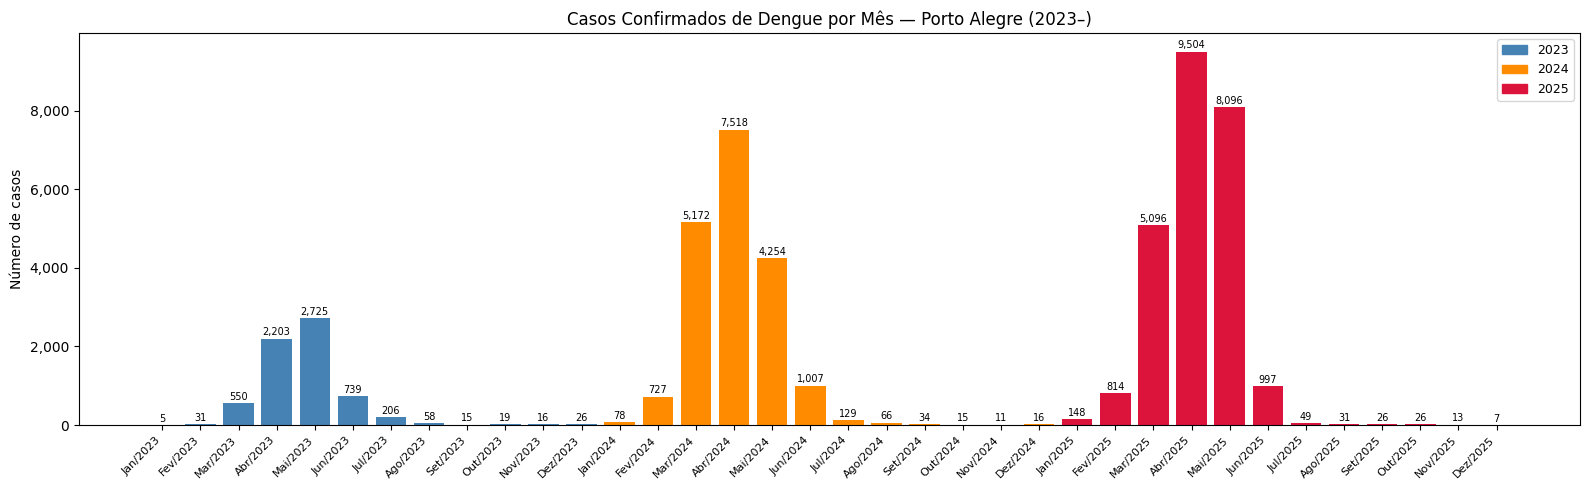

In [25]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

MESES_PT = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

df_plot = df_mensal[df_mensal['ano'] >= 2023].copy()
df_plot['label'] = df_plot.apply(lambda r: f"{MESES_PT[int(r['mes'])-1]}/{int(r['ano'])}", axis=1)

fig, ax = plt.subplots(figsize=(16, 5))
cores = df_plot['ano'].map({2023: 'steelblue', 2024: 'darkorange', 2025: 'crimson', 2026: 'seagreen'})
ax.bar(range(len(df_plot)), df_plot['casos'], color=cores, width=0.8)

ax.set_xticks(range(len(df_plot)))
ax.set_xticklabels(df_plot['label'], rotation=45, ha='right', fontsize=8)

# Anotar valor em cada barra
for i, (_, row) in enumerate(df_plot.iterrows()):
    if row['casos'] > 0:
        ax.text(i, row['casos'] + 30, f"{int(row['casos']):,}", ha='center', va='bottom', fontsize=7)

# Legenda manual por ano
from matplotlib.patches import Patch
anos_presentes = sorted(df_plot['ano'].unique())
mapa_cores = {2023: 'steelblue', 2024: 'darkorange', 2025: 'crimson', 2026: 'seagreen'}
handles = [Patch(color=mapa_cores[a], label=str(a)) for a in anos_presentes if a in mapa_cores]
ax.legend(handles=handles, loc='upper right', fontsize=9)

ax.set_title('Casos Confirmados de Dengue por Mês — Porto Alegre (2023–)')
ax.set_ylabel('Número de casos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()


C:\Users\vinic\AppData\Local\Temp\ipykernel_21128\4093150623.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .assign(mes=lambda d: d['DT_SIN_PRI'].dt.month)


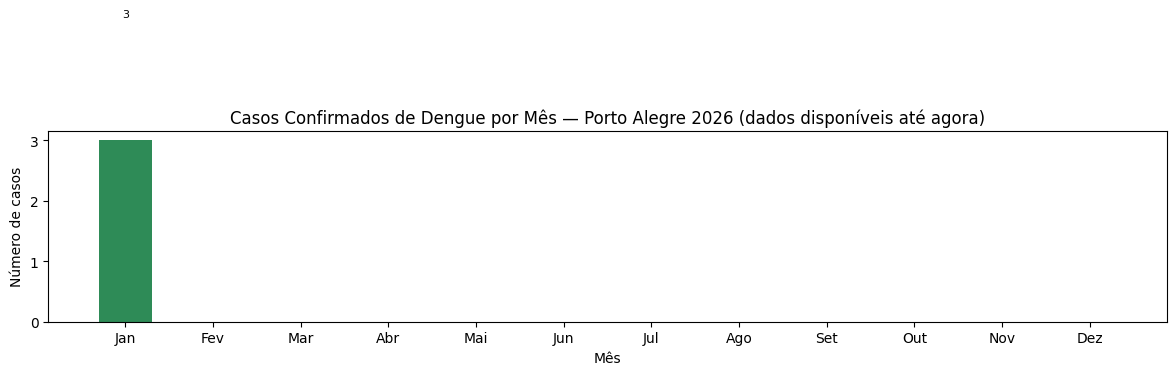

Total de casos em 2026 (base atual): 3
Período coberto: 2026-01-06 até 2026-01-22


In [ ]:
import matplotlib.pyplot as plt

csv_2026 = PASTA_SAIDA / 'dengue_poa_2026.csv'
df_2026 = pd.read_csv(csv_2026, low_memory=False)
df_2026['DT_SIN_PRI'] = pd.to_datetime(df_2026['DT_SIN_PRI'], errors='coerce')

mensal_2026 = (
    df_2026
    .dropna(subset=['DT_SIN_PRI'])
    .assign(mes=lambda d: d['DT_SIN_PRI'].dt.month)
    .groupby('mes')
    .size()
    .reindex(range(1, 13), fill_value=0)
    .reset_index(name='casos')
)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(mensal_2026['mes'], mensal_2026['casos'], color='seagreen', width=0.6)

ax.bar_label(bars, fmt='%d', padding=4, fontsize=9)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(MESES_PT)
ax.set_title('Casos Confirmados de Dengue por Mês — Porto Alegre 2026 (dados disponíveis até agora)')
ax.set_xlabel('Mês')
ax.set_ylabel('Número de casos')

plt.tight_layout()
plt.show()

print(f"Total de casos em 2026 (base atual): {mensal_2026['casos'].sum():,}")
print(f"Período coberto: {df_2026['DT_SIN_PRI'].min().date()} até {df_2026['DT_SIN_PRI'].max().date()}")
